# 3D Illustration of the Joint Multivariate Test

This notebook produces an interactive 3D scatter plot visualizing all five vesset pattern
counts simultaneously across the permutation null distribution.

## Idea

The joint multivariate test (Eq. 1 in the paper) measures the Euclidean distance of the
**observed count vector** $\mathbf{O} = (O_1,\ldots,O_5)^\top$ from the **null mean
vector** $\bar{\mathbf{S}}$. Since 5D space cannot be plotted directly, we use the
following encoding:

| Dimension | Encoding |
|---|---|
| Haflaga | x-axis |
| Dilug | y-axis |
| Week | z-axis |
| Week-Dilug | marker size |
| Dilug-in-Dilug | marker color |

The **null mean** is shown as a blue diamond; the **observed vector** as a red star;
the **Euclidean distance** $D = 19.74$ as a dashed red line connecting the two.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 (registers 3D projection)
from matplotlib.lines import Line2D
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

SEED = 17
np.random.seed(SEED)
PATTERN_LABELS = ['Haflaga', 'Dilug', 'Week', 'Week-Dilug', 'Dilug-in-Dilug']


## 2. Data Loading & Preprocessing

In [2]:
data = pd.read_csv('../data/FilteredData.csv')
df   = data[['ClientID', 'CycleNumber', 'LengthofCycle']].copy()
df['LengthofCycle'] = df['LengthofCycle'] + 1   # halachic haflaga convention

# Patient boundary index pairs (start, finish)  — finish is EXCLUSIVE
change_index = data.index[df['ClientID'] != df['ClientID'].shift()].tolist()
change_index.append(len(df) - 1)
change_indexes = [(change_index[i-1], change_index[i]) for i in range(1, len(change_index))]

print(f"Patients : {df['ClientID'].nunique()}")
print(f"Cycles   : {len(df)}")
print(f"Haflaga units  M = {df['LengthofCycle'].mean():.2f},  SD = {df['LengthofCycle'].std():.2f}")


Patients : 118
Cycles   : 1554
Haflaga units  M = 30.27,  SD = 3.86


## 3. Pattern-Counting Functions

In [3]:
def haflaga_count(lengths):
    """Fixed interval: ≥3 consecutive equal haflaga values."""
    n = 0
    for s, f in change_indexes:
        i = s + 2
        while i < f:
            if lengths[i] == lengths[i-1] == lengths[i-2]:
                n += 1
                while i < f and lengths[i+1] == lengths[i]:
                    i += 1
            i += 1
    return n

def dilug_count(lengths):
    """Arithmetic progression: ≥3 consecutive cycles with constant non-zero diff."""
    n = 0
    for s, f in change_indexes:
        i = s + 2
        while i < f:
            d = lengths[i] - lengths[i-1]
            if d != 0 and d == lengths[i-1] - lengths[i-2]:
                n += 1
                while i < f and lengths[i+1] - lengths[i] == d:
                    i += 1
            i += 1
    return n

def week_count(lengths):
    """Weekly anchor: ≥2 consecutive equal haflaga in {H_min+3, H_min+10, ...}."""
    mn, mx = df['LengthofCycle'].min(), df['LengthofCycle'].max()
    weekly = set(range(int(mn) + 3, int(mx) + 1, 7))
    n = 0
    for s, f in change_indexes:
        i = s + 1
        while i < f:
            if lengths[i] in weekly and lengths[i] == lengths[i-1]:
                n += 1
                while i < f and lengths[i+1] == lengths[i]:
                    i += 1
            i += 1
    return n

def week_dilug_count(lengths):
    """30-day anchor: ≥2 consecutive cycles with haflaga exactly 30."""
    n = 0
    for s, f in change_indexes:
        i = s + 1
        while i < f:
            if lengths[i] == 30 == lengths[i-1]:
                n += 1
                while i < f and lengths[i+1] == lengths[i]:
                    i += 1
            i += 1
    return n

def dilug_in_dilug_count(lengths):
    """Second-order progression: ≥4 consecutive cycles with constant second diff."""
    n = 0
    for s, f in change_indexes:
        i = s + 3
        while i < f:
            b1 = lengths[i-2] - lengths[i-3]
            b2 = lengths[i-1] - lengths[i-2]
            b3 = lengths[i]   - lengths[i-1]
            d1, d2 = b2 - b1, b3 - b2
            if d1 == d2 and d1 != 0:
                n += 1
                b, d = b3, d2
                while i + 1 < f and lengths[i+1] == lengths[i] + b + d:
                    i += 1
                    b += d
            i += 1
    return n

def count_all(lengths):
    return np.array([
        haflaga_count(lengths), dilug_count(lengths),
        week_count(lengths), week_dilug_count(lengths),
        dilug_in_dilug_count(lengths)
    ])


## 4. Observed Counts & Simulations

We run 50,000 permutation iterations. This takes a few minutes.

In [4]:
x_obs = df['LengthofCycle'].values.copy()
observed = count_all(x_obs)
print('Observed counts:', dict(zip(PATTERN_LABELS, observed)))

N_ITER = 50_000
np.random.seed(SEED)
perm_results = []
for _ in range(N_ITER):
    perm_results.append(count_all(np.random.permutation(x_obs)))

perm_df = pd.DataFrame(perm_results, columns=PATTERN_LABELS)
null_mean = perm_df.mean().values
obs_dist  = np.linalg.norm(observed - null_mean)

print(f"\nNull means : {dict(zip(PATTERN_LABELS, null_mean.round(2)))}")
print(f"Observed Euclidean distance from null mean: D = {obs_dist:.3f}")


Observed counts: {'Haflaga': np.int64(26), 'Dilug': np.int64(61), 'Week': np.int64(32), 'Week-Dilug': np.int64(18), 'Dilug-in-Dilug': np.int64(27)}



Null means : {'Haflaga': np.float64(11.29), 'Dilug': np.float64(48.92), 'Week': np.float64(27.0), 'Week-Dilug': np.float64(16.27), 'Dilug-in-Dilug': np.float64(27.1)}
Observed Euclidean distance from null mean: D = 19.758


## 5. Interactive 3D Plot (Plotly)

> **Note:** Plotly renders interactively in Jupyter/JupyterLab. In Overleaf or PDF,
> use the static matplotlib version in Section 6 instead.
>
> The interactive version allows you to rotate, zoom, and hover over individual
> simulated points to inspect all five pattern counts simultaneously.


In [5]:
# Subsample for readability (4,000 of 50,000 points)
np.random.seed(42)
idx = np.random.choice(len(perm_df), 4000, replace=False)
sub = perm_df.iloc[idx]

wd_vals  = sub['Week-Dilug'].values
did_vals = sub['Dilug-in-Dilug'].values

# Normalise Week-Dilug → marker size [4, 14]
wd_norm = 4 + 10 * (wd_vals - wd_vals.min()) / (wd_vals.max() - wd_vals.min() + 1e-9)

fig_plotly = go.Figure()

# ── Null cloud ────────────────────────────────────────────────────────────────
fig_plotly.add_trace(go.Scatter3d(
    x=sub['Haflaga'].values,
    y=sub['Dilug'].values,
    z=sub['Week'].values,
    mode='markers',
    name='Permutation null (N=4,000 shown)',
    marker=dict(
        size=wd_norm,
        color=did_vals,
        colorscale='Blues',
        opacity=0.35,
        colorbar=dict(
            title=dict(text='Dilug-in-Dilug count', side='right', font=dict(size=11)),
            thickness=14, len=0.5, x=1.02,
        ),
        line=dict(width=0),
    ),
    hovertemplate=(
        '<b>Simulated point</b><br>'
        'Haflaga: %{x}<br>Dilug: %{y}<br>Week: %{z}<br>'
        'Week-Dilug (→size): %{customdata[0]}<br>'
        'Dilug-in-Dilug (→color): %{marker.color:.0f}<extra></extra>'
    ),
    customdata=np.stack([wd_vals], axis=-1),
))

# ── Null mean ─────────────────────────────────────────────────────────────────
fig_plotly.add_trace(go.Scatter3d(
    x=[null_mean[0]], y=[null_mean[1]], z=[null_mean[2]],
    mode='markers',
    name=f'Null mean  ({null_mean[0]:.1f}, {null_mean[1]:.1f}, {null_mean[2]:.1f})',
    marker=dict(size=10, color='#2E86AB', symbol='diamond', opacity=1.0,
                line=dict(color='white', width=2)),
    hovertemplate=(
        '<b>Null mean</b><br>'
        'Haflaga: %{x:.2f}<br>Dilug: %{y:.2f}<br>Week: %{z:.2f}'
        '<extra></extra>'
    ),
))

# ── Observed vector ───────────────────────────────────────────────────────────
fig_plotly.add_trace(go.Scatter3d(
    x=[observed[0]], y=[observed[1]], z=[observed[2]],
    mode='markers',
    name=f'Observed  ({observed[0]}, {observed[1]}, {observed[2]})',
    marker=dict(size=13, color='#C73E1D', symbol='cross', opacity=1.0,
                line=dict(color='white', width=2)),
    hovertemplate=(
        '<b>Observed data</b><br>'
        'Haflaga: %{x}<br>Dilug: %{y}<br>Week: %{z}'
        '<extra></extra>'
    ),
))

# ── Distance line: null mean → observed ──────────────────────────────────────
fig_plotly.add_trace(go.Scatter3d(
    x=[null_mean[0], observed[0]],
    y=[null_mean[1], observed[1]],
    z=[null_mean[2], observed[2]],
    mode='lines',
    name=f'Distance  D = {obs_dist:.2f}',
    line=dict(color='#C73E1D', width=5, dash='dash'),
    hoverinfo='skip',
))

# ── Layout ────────────────────────────────────────────────────────────────────
fig_plotly.update_layout(
    title=dict(
        text=(
            'Joint multivariate test: observed count vector vs. permutation null<br>'
            '<sup>Axes: Haflaga / Dilug / Week  ·  Size → Week-Dilug  ·  '
            'Color → Dilug-in-Dilug</sup>'
        ),
        x=0.5, xanchor='center', font=dict(size=14, family='serif'),
    ),
    scene=dict(
        xaxis=dict(title='Haflaga count', backgroundcolor='rgb(245,245,252)',
                   gridcolor='white', showbackground=True),
        yaxis=dict(title='Dilug count',   backgroundcolor='rgb(245,252,245)',
                   gridcolor='white', showbackground=True),
        zaxis=dict(title='Week count',    backgroundcolor='rgb(252,245,245)',
                   gridcolor='white', showbackground=True),
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9)),
        aspectmode='auto',
    ),
    legend=dict(x=0.01, y=0.98, bgcolor='rgba(255,255,255,0.85)',
                bordercolor='#ccc', borderwidth=1, font=dict(size=11)),
    margin=dict(l=0, r=80, t=100, b=0),
    width=960, height=700,
    paper_bgcolor='white',
    font=dict(family='serif'),
)

fig_plotly.show()


## 6. Static 3D Plot (Matplotlib — for publication / PDF export)

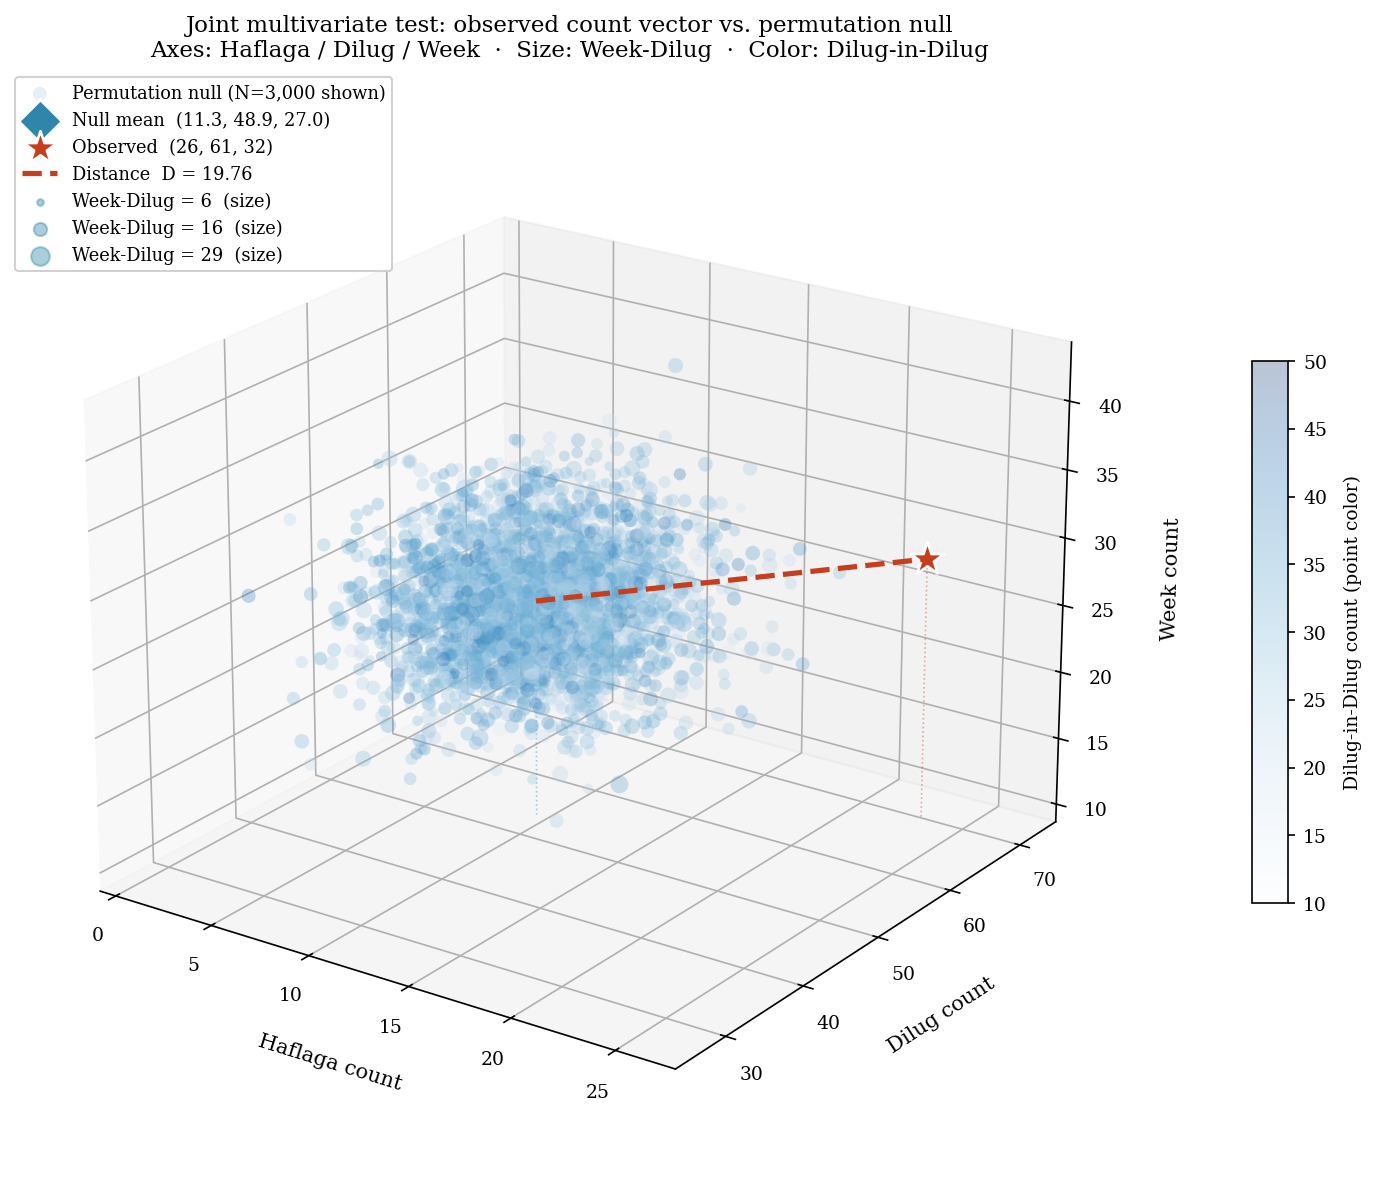

Figures saved to figures/fig5_3d_joint_test.pdf and .png


In [6]:
plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'serif',
    'axes.titlesize': 11, 'axes.labelsize': 10, 'font.size': 9,
})

# Subsample for plot clarity
np.random.seed(42)
idx3 = np.random.choice(len(perm_df), 3000, replace=False)
sub3 = perm_df.iloc[idx3]

x3  = sub3['Haflaga'].values
y3  = sub3['Dilug'].values
z3  = sub3['Week'].values
wd3 = sub3['Week-Dilug'].values
did3= sub3['Dilug-in-Dilug'].values

# Marker size: Week-Dilug → [10, 80]
sz3 = 10 + 70 * (wd3 - wd3.min()) / (wd3.max() - wd3.min() + 1e-9)

fig3d = plt.figure(figsize=(12, 8))
ax3d  = fig3d.add_subplot(111, projection='3d')

# Null cloud
sc3 = ax3d.scatter(x3, y3, z3, c=did3, cmap='Blues', s=sz3,
                   alpha=0.28, linewidths=0,
                   vmin=did3.min(), vmax=did3.max(),
                   label='Permutation null (N=3,000 shown)')

# Null mean
ax3d.scatter(*null_mean[:3], color='#2E86AB', s=220, marker='D',
             edgecolors='white', linewidths=1.5, zorder=10,
             label=f'Null mean  ({null_mean[0]:.1f}, {null_mean[1]:.1f}, {null_mean[2]:.1f})')

# Observed
ax3d.scatter(*observed[:3], color='#C73E1D', s=280, marker='*',
             edgecolors='white', linewidths=1.2, zorder=11,
             label=f'Observed  ({observed[0]}, {observed[1]}, {observed[2]})')

# Distance line
ax3d.plot([null_mean[0], observed[0]],
          [null_mean[1], observed[1]],
          [null_mean[2], observed[2]],
          color='#C73E1D', lw=2.5, ls='--', zorder=12,
          label=f'Distance  D = {obs_dist:.2f}')

# Vertical drop lines to floor (visual aid)
for pt, c in [(observed[:3], '#C73E1D'), (null_mean[:3], '#2E86AB')]:
    ax3d.plot([pt[0], pt[0]], [pt[1], pt[1]],
              [pt[2], ax3d.get_zlim()[0]], color=c, lw=0.8, ls=':', alpha=0.4)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='Blues',
                            norm=mcolors.Normalize(vmin=did3.min(), vmax=did3.max()))
sm.set_array([])
cbar = fig3d.colorbar(sc3, ax=ax3d, shrink=0.5, pad=0.08, aspect=15)
cbar.set_label('Dilug-in-Dilug count (point color)', fontsize=9, labelpad=8)

# Size legend
for wd_val, sz_val in [(int(wd3.min()), 10), (int(np.median(wd3)), 40), (int(wd3.max()), 80)]:
    ax3d.scatter([], [], [], s=sz_val, c='#2E86AB', alpha=0.4,
                 label=f'Week-Dilug = {wd_val}  (size)')

ax3d.set_xlabel('Haflaga count', labelpad=10)
ax3d.set_ylabel('Dilug count',   labelpad=10)
ax3d.set_zlabel('Week count',    labelpad=10)
ax3d.set_title(
    ('Joint multivariate test: observed count vector vs. permutation null\n'
     'Axes: Haflaga / Dilug / Week  ·  Size: Week-Dilug  ·  Color: Dilug-in-Dilug'),
    fontsize=11, pad=16
)
ax3d.legend(loc='upper left', fontsize=8.5, framealpha=0.9,
            bbox_to_anchor=(-0.02, 1.02))
ax3d.view_init(elev=22, azim=-55)

plt.tight_layout()
plt.savefig('../paper/figures/fig5_3d_joint_test.pdf', bbox_inches='tight', dpi=150)
plt.savefig('../paper/figures/fig5_3d_joint_test.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figures saved to figures/fig5_3d_joint_test.pdf and .png")


## 7. Save Interactive HTML (for supplementary / presentations)

In [7]:
fig_plotly.write_html('figures/fig5_3d_joint_test_interactive.html')
print("Interactive HTML saved to figures/fig5_3d_joint_test_interactive.html")
print("Open this file in any browser to get a fully rotatable, zoomable version.")


Interactive HTML saved to figures/fig5_3d_joint_test_interactive.html
Open this file in any browser to get a fully rotatable, zoomable version.


## 8. Key Numbers

Quick summary of the joint test result.


In [8]:
null_dists = np.linalg.norm(perm_df.values - null_mean, axis=1)
p_joint    = (null_dists >= obs_dist).mean()

print("=" * 52)
print(f"  Observed count vector :  {observed}")
print(f"  Null mean vector      :  {null_mean.round(2)}")
print(f"  Euclidean distance D  :  {obs_dist:.4f}")
print(f"  One-sided p-value     :  {p_joint:.4f}")
print(f"  Percentile of null    :  {100*(1-p_joint):.1f}th")
print("=" * 52)


  Observed count vector :  [26 61 32 18 27]
  Null mean vector      :  [11.29 48.92 27.   16.27 27.1 ]
  Euclidean distance D  :  19.7577
  One-sided p-value     :  0.0086
  Percentile of null    :  99.1th
